# Import Libraries

In [17]:
from sklearn.datasets import make_classification
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Create Dataset

In [3]:
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.82, 0.18],   # کالس ۱ )تقلب( کمتر از کالس ۰ است
    flip_y=0.05,             # کمی نویز واقع گرایانه در برچسب ها
    class_sep=0.9,
    random_state=42
)

feature_names = ['accuracy_pct', 'reaction_time_ms', 'headshot_rate_pct', 'reports_count']

In [10]:
df = pd.DataFrame(np.concat([X, y[:, np.newaxis]], axis=1), columns=feature_names+['is_cheater'])
df.head()

,accuracy_pct,reaction_time_ms,headshot_rate_pct,reports_count,is_cheater
0,-0.337601,-2.158004,0.031607,-1.760809,0.0
1,-0.196829,0.979392,1.610221,-0.668144,1.0
2,-0.366725,0.101598,0.596915,0.817766,0.0
3,-1.392378,-1.657398,1.293200,-0.939335,0.0
4,1.637529,0.547472,3.059684,0.113270,1.0


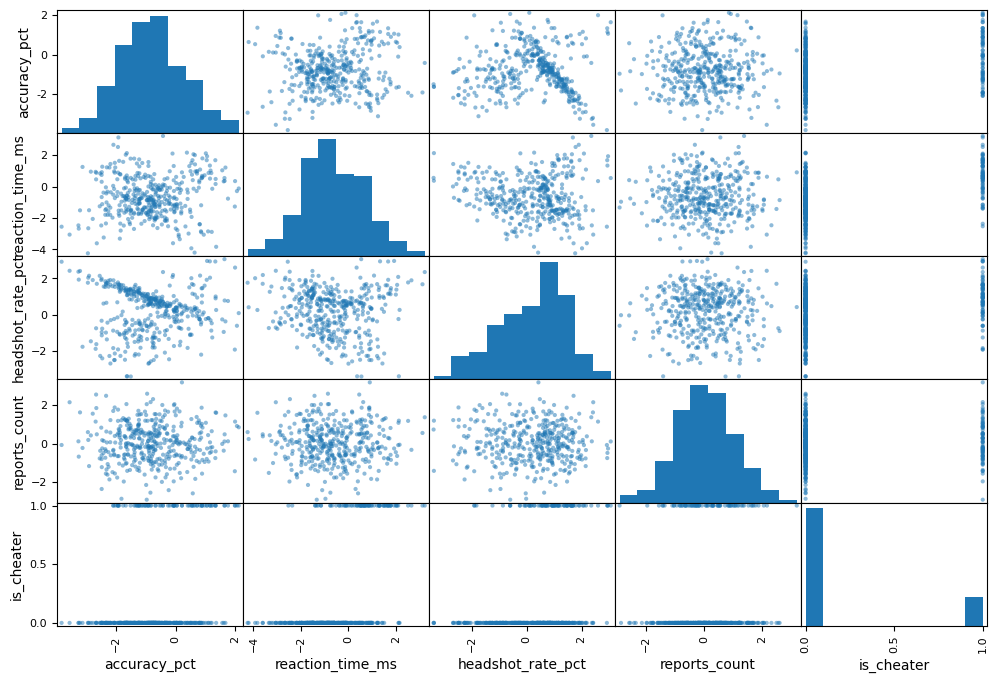

In [14]:
scatter_matrix(df, figsize=(12, 8))
plt.show()

# Split Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df[feature_names], df['is_cheater'], 
                                                    stratify=df['is_cheater'], test_size=0.3, random_state=42)

In [18]:
models = {'no_depth': DecisionTreeClassifier(random_state=42),
         'depth_1': DecisionTreeClassifier(max_depth=1, random_state=42),
         'depth_4': DecisionTreeClassifier(max_depth=4, random_state=42)}

In [20]:
results = []

for key, model in models.items():
    print(f"Training tree named: {key}")
    model.fit(X_train, y_train)
    results.append([model.score(X_train, y_train), model.score(X_test, y_test)])

Training tree named: no_depth
Training tree named: depth_1
Training tree named: depth_4


In [25]:
results_df = pd.DataFrame(results, columns=['train_accuracy', 'test_accuracy'], index=models.keys())
results_df['Train-Test-Acc-Diff'] = results_df['train_accuracy'] - results_df['test_accuracy']
results_df.sort_values('Train-Test-Acc-Diff')

,train_accuracy,test_accuracy,Train-Test-Acc-Diff
depth_1,0.850000,0.758333,0.091667
depth_4,0.960714,0.850000,0.110714
no_depth,1.000000,0.816667,0.183333


# Reason

مدل با عمق یک آندرفیت شده است. دقت روی داده آموزش از همه کمتر است. نتوانسته است داده و الگوهای موجود را یاد بگیرد.

مدل بدون محدودیت عمق، اورفیت شده است. چنانچه دقت روی داده آموزش بالا باشد ولی روی داده آزمون افت داشته باشیم (بسته به مساله یا افت شدید باشد یا حتی کم. چون فرض کنید مساله بسیار ساده باشد و نیاز باشد دقت آزمون به آموزش نزدیک باشد)

اگر صرفا روی تفاضل دقتها تمرکز کنیم مدل با عمق یک قابل تعمیم است که اشتباه است. دقت مدل روی هر دو داده پایین است.
مدل با عمق چهار هم دقت آموزش خوبی دارد و هم دقت آزمون. به بهای افت دقت آموزش، دقت آزمون را افزایش داده ایم.

مدل بدون محدودیت عمق، واریانس بالا و بایاس کم.

    مدل با محدودیت عمق 1 بایاس بالا، واریانس کم

مدل با محدودیت عمق 4، بایاس کم، واریانس کم

البته این نتیجه‌گیری‌ها حاصل مقایسه سه مدل است و شاید با دیدن مدلهای دیگر تصمیم‌گیری متفاوتی داشته باشیم.

ه: به نظر من در صورت برابری دقت آزمون دو مدل، مدلی که اختلاف آموزش و آزمونش کم باشد انتخاب میشود.